In [31]:
import warnings
import numpy as np
import pandas as pd
from scipy.stats import hypergeom, multinomial
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn import JointGrid
from empiricaldist import Pmf
from utils import (
    decorate, 
    make_uniform, 
    make_joint, 
    plot_contour, 
    marginal
)

sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

## 15.1 The Grizzly Bear Problem

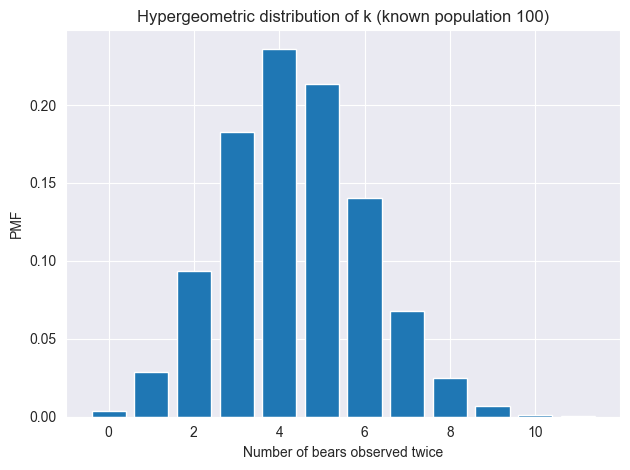

In [5]:
N = 100
K = 23
n = 19

ks = np.arange(12)
ps = hypergeom(N, K, n).pmf(ks)

plt.bar(ks, ps)
decorate(
    xlabel='Number of bears observed twice',
    ylabel='PMF',
    title='Hypergeometric distribution of k (known population 100)'
)

## 15.2 The Update

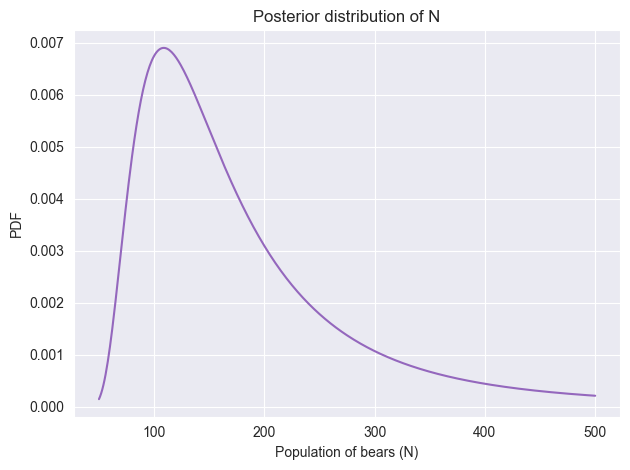

In [7]:
Ns = np.arange(50, 501)
K = 23
n = 19
k = 4

prior_N = make_uniform(Ns, name='N')
likelihood = hypergeom(Ns, K, n).pmf(k)

posterior_N = prior_N * likelihood
posterior_N.normalize()

posterior_N.plot(color='C4')
decorate(
    xlabel='Population of bears (N)',
    ylabel='PDF',
    title='Posterior distribution of N'
)

In [8]:
posterior_N.max_prob()

109

In [9]:
posterior_N.mean()

173.79880627085805

In [10]:
posterior_N.credible_interval(0.9)

array([ 77., 363.])

## 15.3 Two-Parameter Model

In [12]:
K = 23
n = 19
k = 4
N = 100
p = 0.2

k10 = 23 - 4
k01 = 19 - 4
k11 = 4
k00 = N - (k01 + k10 + k11)
x = [k00, k01, k10, k11]

In [13]:
p = 0.2
q = 1-p
y = [q*q, q*p, p*q, p*p]
y

[0.6400000000000001,
 0.16000000000000003,
 0.16000000000000003,
 0.04000000000000001]

In [15]:
likelihood = multinomial.pmf(x, N, y)
likelihood

0.0016664011988507257

## 15.4 The Prior

In [20]:
qs = np.linspace(0, 0.99, num=100)
prior_p = make_uniform(qs, name='p')

joint_prior = make_joint(prior_p, prior_N)
joint_pmf = Pmf(joint_prior.stack())
joint_pmf.head(3)

N   p   
50  0.00    0.000022
    0.01    0.000022
    0.02    0.000022
dtype: float64

## 15.5 The Update

In [21]:
likelihood = joint_pmf.copy()
observed = k01 + k10 + k11

for N, p in joint_pmf.index:
    k00 = N - observed
    x = [k00, k01, k10, k11]
    q = 1 - p
    y = [q*q, q*p, p*q, p*p]
    likelihood[N, p] = multinomial.pmf(x, N, y)

posterior_pmf = joint_pmf * likelihood
posterior_pmf.normalize()

2.9678796190279657e-05

In [23]:
joint_posterior = posterior_pmf.unstack()
joint_posterior

p,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,...,0.90,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99
N,,,,,,,,,,,,,,,,,,,,,
50,0.0,6.936668e-60,1.693097e-47,2.323608e-40,2.251960e-35,1.442178e-31,1.652257e-28,5.760210e-26,8.390407e-24,6.264635e-22,...,1.487630e-35,5.249448e-38,8.966390e-41,6.113357e-44,1.254446e-47,4.999900e-52,1.858578e-57,1.628378e-64,1.533008e-74,8.146814e-92
51,0.0,2.667154e-59,6.379120e-47,8.576956e-40,8.141980e-35,5.106143e-31,5.727435e-28,1.954479e-25,2.786028e-23,2.035192e-21,...,5.836088e-37,1.668113e-39,2.251254e-42,1.175175e-45,1.771664e-49,4.903748e-54,1.166615e-59,5.749427e-67,2.405644e-77,3.196058e-95
52,0.0,9.709432e-59,2.275560e-46,2.997450e-39,2.787070e-34,1.711652e-30,1.879711e-27,6.278736e-25,8.758636e-23,6.259843e-21,...,2.167690e-38,5.018637e-41,5.351551e-44,2.138819e-47,2.368968e-51,4.553480e-56,6.933029e-62,1.921951e-69,3.574100e-80,1.187107e-98
53,0.0,3.362396e-58,7.721915e-46,9.965063e-39,9.075591e-34,5.458173e-30,5.868559e-27,1.918769e-24,2.619369e-22,1.831601e-20,...,7.659171e-40,1.436334e-42,1.210164e-45,3.703009e-49,3.013327e-53,4.022241e-58,3.919472e-64,6.111805e-72,5.051394e-83,4.194445e-102
54,0.0,1.112226e-57,2.502943e-45,3.164443e-38,2.822872e-33,1.662525e-29,1.750092e-26,5.600959e-24,7.482491e-22,5.119027e-20,...,2.584970e-41,3.926578e-44,2.613954e-47,6.123851e-51,3.661192e-55,3.393766e-60,2.116515e-66,1.856461e-74,6.819382e-86,1.415625e-105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,0.0,8.742606e-18,2.490220e-09,3.634514e-06,3.407196e-05,1.915893e-05,1.745900e-06,4.376479e-08,4.134486e-10,1.801831e-12,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
497,0.0,9.278014e-18,2.589606e-09,3.702827e-06,3.400034e-05,1.872243e-05,1.670394e-06,4.098590e-08,3.789142e-10,1.615625e-12,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
498,0.0,9.844574e-18,2.692510e-09,3.771798e-06,3.392323e-05,1.829283e-05,1.597887e-06,3.837707e-08,3.472066e-10,1.448421e-12,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


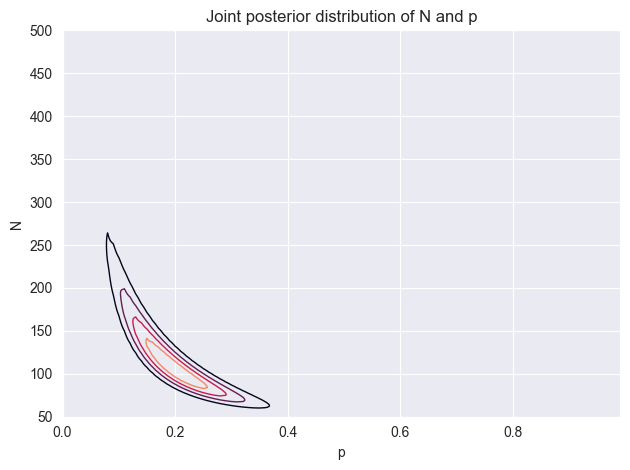

In [25]:
plot_contour(joint_posterior)
decorate(title='Joint posterior distribution of N and p')

In [27]:
posterior2_p = marginal(joint_posterior, 0)
posterior2_N = marginal(joint_posterior, 1)

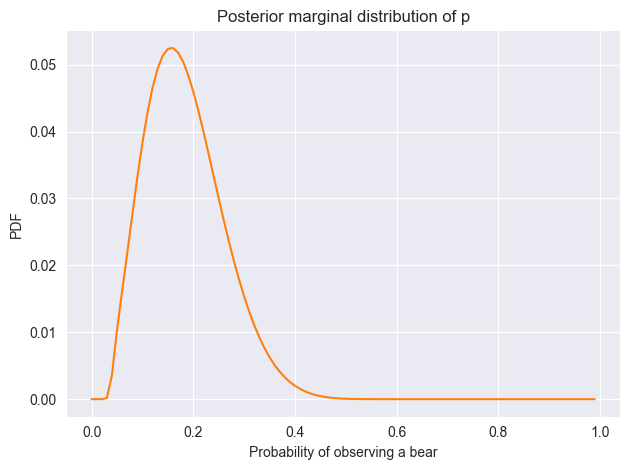

In [28]:
posterior2_p.plot(color='C1')
decorate(
    xlabel='Probability of observing a bear',
    ylabel='PDF',
    title='Posterior marginal distribution of p'
)

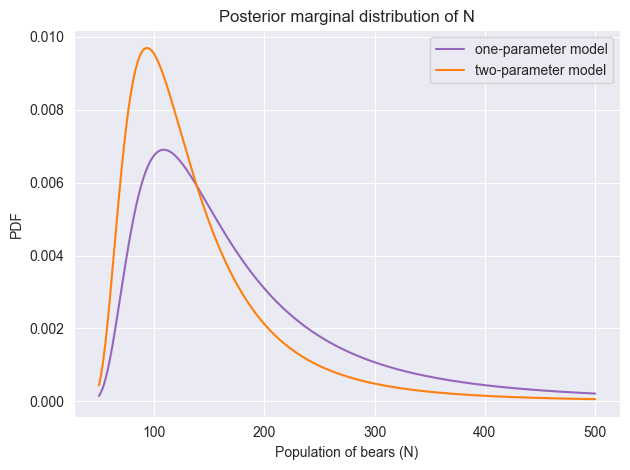

In [29]:
posterior_N.plot(label='one-parameter model', color='C4')
posterior2_N.plot(label='two-parameter model', color='C1')
decorate(
    xlabel='Population of bears (N)',
    ylabel='PDF',
    title='Posterior marginal distribution of N'
)

In [30]:
print(posterior_N.mean(), posterior_N.credible_interval(0.9))
print(posterior2_N.mean(), posterior2_N.credible_interval(0.9))

173.79880627085805 [ 77. 363.]
138.750521364726 [ 68. 277.]


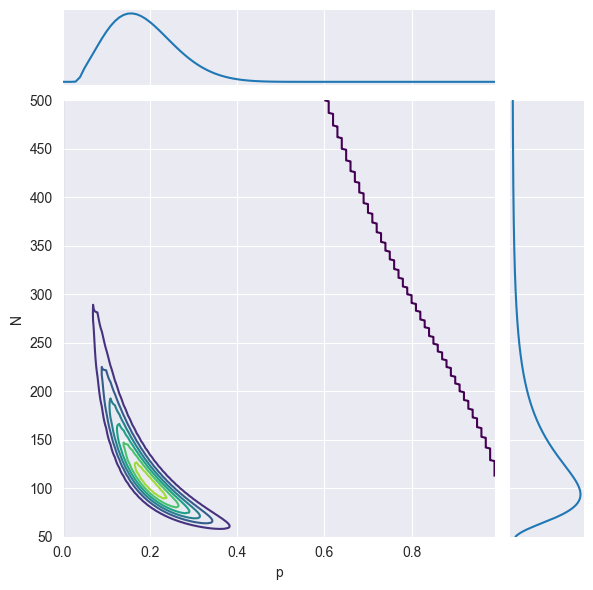

In [32]:

def joint_plot(joint, **options):
    """Show joint and marginal distributions.
    
    joint: DataFrame that represents a joint distribution
    options: passed to JointGrid
    """
    # get the names of the parameters
    x = joint.columns.name
    x = 'x' if x is None else x

    y = joint.index.name
    y = 'y' if y is None else y

    # make a JointGrid with minimal data
    data = pd.DataFrame({x:[0], y:[0]})
    g = JointGrid(x=x, y=y, data=data, **options)

    # replace the contour plot
    g.ax_joint.contour(joint.columns, 
                       joint.index, 
                       joint, 
                       cmap='viridis')
    
    # replace the marginals
    marginal_x = marginal(joint, 0)
    g.ax_marg_x.plot(marginal_x.qs, marginal_x.ps)
    
    marginal_y = marginal(joint, 1)
    g.ax_marg_y.plot(marginal_y.ps, marginal_y.qs)


joint_plot(joint_posterior)

## 15.7 The Lincoln Index Problem

In [33]:
k10 = 20 - 3 
k01 = 15 -3
k11 = 3

In [35]:
p0, p1 = 0.2, 0.15

def compute_probs(p0, p1):
    q0 = 1 - p0
    q1 = 1 - p1
    return [q0*q1, q0*p1, p0*q1, p0*p1]


y = compute_probs(p0, p1)
y

[0.68, 0.12, 0.17, 0.03]

In [36]:
qs = np.arange(32, 350, step=5) 
prior_N = make_uniform(qs, name='N')
prior_N.head(3)

,probs
N,
32,0.015625
37,0.015625
42,0.015625


In [37]:
data = np.array([0, k01, k10, k11])

In [38]:
likelihood = prior_N.copy()
observed = data.sum()
x = data.copy()

for N in prior_N.qs:
    x[0] = N - observed
    likelihood[N] = multinomial.pmf(x, N, y)

In [39]:
posterior_N = prior_N * likelihood
posterior_N.normalize()

0.0003425201572557094

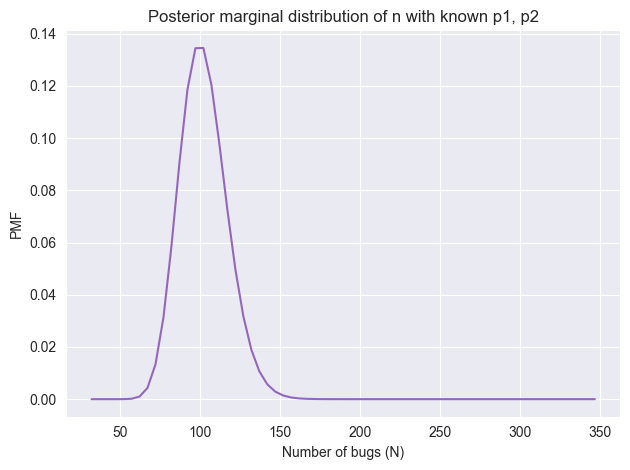

In [40]:
posterior_N.plot(color='C4')

decorate(
    xlabel='Number of bugs (N)',
    ylabel='PMF',
    title='Posterior marginal distribution of n with known p1, p2'
)

In [42]:
print(
    posterior_N.mean(), 
    posterior_N.credible_interval(0.9)
)

102.1249999999998 [ 77. 127.]


## 15.8 Three-Parameter Model

In [55]:
qs = np.linspace(0, 1, num=51)
prior_p0 = make_uniform(qs, name='p0')
prior_p1 = make_uniform(qs, name='p1')

In [56]:
joint2 = make_joint(prior_p0, prior_N)
joint2.head()

p0,0.00,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,...,0.82,0.84,0.86,0.88,0.90,0.92,0.94,0.96,0.98,1.00
N,,,,,,,,,,,,,,,,,,,,,
32,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,...,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306
37,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,...,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306
42,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,...,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306
47,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,...,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306
52,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,...,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306,0.000306


In [57]:
joint2_pmf = Pmf(joint2.stack())
joint2_pmf.head(3)

N   p0  
32  0.00    0.000306
    0.02    0.000306
    0.04    0.000306
dtype: float64

In [58]:
joint3 = make_joint(prior_p1, joint2_pmf)
joint3.head()

p1           0.00      0.02      0.04      0.06      0.08      0.10      0.12  \
N  p0                                                                           
32 0.00  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006   
   0.02  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006   
   0.04  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006   
   0.06  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006   
   0.08  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006   

p1           0.14      0.16      0.18  ...      0.82      0.84      0.86  \
N  p0                                  ...                                 
32 0.00  0.000006  0.000006  0.000006  ...  0.000006  0.000006  0.000006   
   0.02  0.000006  0.000006  0.000006  ...  0.000006  0.000006  0.000006   
   0.04  0.000006  0.000006  0.000006  ...  0.000006  0.000006  0.000006   
   0.06  0.000006  0.000006  0.000006  ...  0.000006  0.000006  0.000006   
   0.08  0.000006  0.000006  0.000006  ...  0.000006  0.000006  0.000006   

p1           0.88      0.90      0.92      0.94      0.96      0.98      1.00  
N  p0                                                                          
32 0.00  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  
   0.02  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  
   0.04  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  
   0.06  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  
   0.08  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  0.000006  

[5 rows x 51 columns]

In [59]:
joint3_pmf = Pmf(joint3.stack())
joint3_pmf.head(3)

N   p0   p1  
32  0.0  0.00    0.000006
         0.02    0.000006
         0.04    0.000006
dtype: float64

In [60]:
likelihood = joint3_pmf.copy()
observed = data.sum()
x = data.copy()

for N, p0, p1 in joint3_pmf.index:
    x[0] = N - observed
    y = compute_probs(p0, p1)
    likelihood[N, p0, p1] = multinomial.pmf(x, N, y)

In [65]:
posterior_pmf = joint3_pmf * likelihood
posterior_pmf.normalize()

8.941088283758206e-06

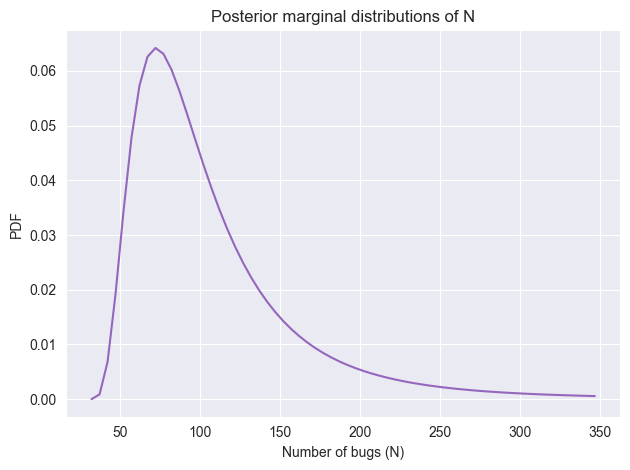

In [66]:
posterior_N = posterior_pmf.marginal(0)
posterior_N.plot(color='C4')

decorate(
    xlabel='Number of bugs (N)',
    ylabel='PDF',
    title='Posterior marginal distributions of N'
)

In [67]:
posterior_N.mean()

105.76561732196238

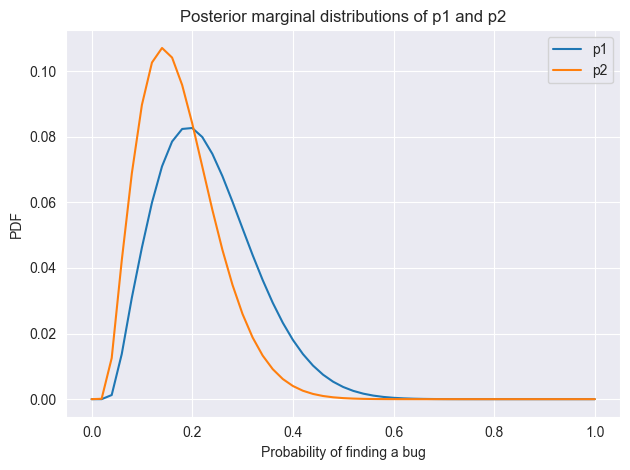

In [68]:
posterior_p1 = posterior_pmf.marginal(1)
posterior_p2 = posterior_pmf.marginal(2)

posterior_p1.plot(label='p1')
posterior_p2.plot(label='p2')

decorate(
    xlabel='Probability of finding a bug',
    ylabel='PDF',
    title='Posterior marginal distributions of p1 and p2'
)

In [69]:
posterior_p1.mean(), posterior_p1.credible_interval(0.9)

(0.2297065971677734, array([0.1, 0.4]))

In [70]:
posterior_p2.mean(), posterior_p2.credible_interval(0.9)

(0.17501172155925765, array([0.06, 0.32]))